In [1]:
#https://ranasinghiitkgp.medium.com/feature-engineering-using-featuretools-with-code-10f8c83e5f68

In [2]:
import featuretools as ft
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("../data/bigSmartSales.csv")
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
df.isna().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [5]:
df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace = True)
df['Outlet_Size'].fillna("missing", inplace = True)

C:\Users\H P\AppData\Local\Temp\ipykernel_84616\2409279222.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace = True)
C:\Users\H P\AppData\Local\Temp\ipykernel_84616\2409279222.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [ ]:
fat_content_dict = {'Low Fat':0, 'Regular':1, 'LF':0, 'reg':1, 'low fat':0}
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace(fat_content_dict, regex=True)

df['id'] = df['Item_Identifier'] + df['Outlet_Identifier']
df.drop(['Item_Identifier'], axis=1, inplace=True)


C:\Users\H P\AppData\Local\Temp\ipykernel_84616\1474495892.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Item_Fat_Content'] = df['Item_Fat_Content'].replace(fat_content_dict, regex=True)


In [8]:
df.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,id
0,9.30,0,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,FDA15OUT049
1,5.92,1,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,DRC01OUT018
2,17.50,0,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,FDN15OUT049
3,19.20,1,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,missing,Tier 3,Grocery Store,732.3800,FDX07OUT010
4,8.93,0,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,NCD19OUT013


In [9]:
from sklearn.preprocessing import LabelEncoder
colonnes_a_encoder = ['Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type','Outlet_Identifier']
le = LabelEncoder()
for col in colonnes_a_encoder:
    df[col] = le.fit_transform(df[col].astype(str)) 

df.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,id
0,9.30,0,0.016047,4,249.8092,9,1999,1,0,1,3735.1380,FDA15OUT049
1,5.92,1,0.019278,14,48.2692,3,2009,1,2,2,443.4228,DRC01OUT018
2,17.50,0,0.016760,10,141.6180,9,1999,1,0,1,2097.2700,FDN15OUT049
3,19.20,1,0.000000,6,182.0950,0,1998,3,2,0,732.3800,FDX07OUT010
4,8.93,0,0.000000,9,53.8614,1,1987,0,2,1,994.7052,NCD19OUT013


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return r2,rmse

In [11]:
features = ['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP',
            'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size',
            'Outlet_Location_Type', 'Outlet_Type']

X = df[features]
y = df['Item_Outlet_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [13]:
from sklearn.linear_model import Lasso, Ridge


linearmodel = LinearRegression()
ridgemodel = Ridge(alpha=1.0)
lassomodel = Lasso(alpha=1.0)

In [14]:
r2,rmse = evaluate_model(linearmodel, X_train, y_train, X_test, y_test)
r2_ridge,rmse_ridge = evaluate_model(ridgemodel, X_train, y_train, X_test, y_test)
r2_lasso,rmse_lasso = evaluate_model(lassomodel, X_train, y_train, X_test, y_test)


print(f"Linear Regression - R²: {r2:.2f}, RMSE: {rmse:.2f}")
print(f"Ridge Regression - R²: {r2_ridge:.2f}, RMSE: {rmse_ridge:.2f}")
print(f"Lasso Regression - R²: {r2_lasso:.2f}, RMSE: {rmse_lasso:.2f}")

Linear Regression - R²: 0.52, RMSE: 1142.09
Ridge Regression - R²: 0.52, RMSE: 1141.90
Lasso Regression - R²: 0.52, RMSE: 1141.55


Application autofeat

In [15]:
from autofeat import AutoFeatRegressor 

af = AutoFeatRegressor( feateng_steps=2,n_jobs=-1)  
X_train_af = af.fit_transform(X_train, y_train)
X_test_af = af.transform(X_test)
X_train_af.head()
print(f"Nombre de nouvelles features créées : {X_train_af.shape[1] - X_train.shape[1]}")


c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\autofeat\featsel.py:270: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  if np.max(np.abs(correlations[c].ravel()[:i])) < 0.9:


Nombre de nouvelles features créées : 24


c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [16]:
print(f"Nombre de nouvelles features créées : {X_train_af.shape[1] - X_train.shape[1]}")


Nombre de nouvelles features créées : 24


In [17]:
r2_af,rmse_af = evaluate_model(linearmodel, X_train_af, y_train, X_test_af, y_test)
r2_ridge_af,rmse_ridge_af = evaluate_model(ridgemodel, X_train_af, y_train, X_test_af, y_test)
r2_lasso_af,rmse_lasso_af = evaluate_model(lassomodel, X_train_af, y_train, X_test_af, y_test)

print(f"Linear Regression with AutoFeat - R²: {r2_af:.2f}, RMSE: {rmse_af:.2f}")
print(f"Ridge Regression with AutoFeat - R²: {r2_ridge_af:.2f}, RMSE: {rmse_ridge_af:.2f}")
print(f"Lasso Regression with AutoFeat - R²: {r2_lasso_af:.2f}, RMSE: {rmse_lasso_af:.2f}")

c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.54741e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Linear Regression with AutoFeat - R²: 0.62, RMSE: 1019.54
Ridge Regression with AutoFeat - R²: 0.62, RMSE: 1019.12
Lasso Regression with AutoFeat - R²: 0.62, RMSE: 1019.16


c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.008e+09, tolerance: 2.017e+06
  model = cd_fast.enet_coordinate_descent(


Application featuretools

In [ ]:

es = ft.EntitySet(id = 'sales')

es.add_dataframe(dataframe_name = 'bigmart', dataframe = df, index = 'id')

c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\woodwork\type_sys\utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\woodwork\type_sys\utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(


Entityset: sales
  DataFrames:
    bigmart [Rows: 8523, Columns: 12]
  Relationships:
    No relationships

In [19]:
es.normalize_dataframe(base_dataframe_name='bigmart', new_dataframe_name='outlet', index = 'Outlet_Identifier', 
            additional_columns = ['Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'])


Entityset: sales
  DataFrames:
    bigmart [Rows: 8523, Columns: 8]
    outlet [Rows: 10, Columns: 5]
  Relationships:
    bigmart.Outlet_Identifier -> outlet.Outlet_Identifier

In [20]:
feature_matrix, feature_names = ft.dfs(entityset=es, 
target_dataframe_name = 'bigmart', 
max_depth = 2, 
verbose = 1, 
n_jobs = 1)

Built 48 features
Elapsed: 00:00 | Progress:  95%|█████████▌

c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\featuretools\computational_backends\feature_set_calculator.py:785: FutureWarning: The provided callable <function mean at 0x000001AA2BF060E0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  ).agg(to_agg)
c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\featuretools\computational_backends\feature_set_calculator.py:785: FutureWarning: The provided callable <function min at 0x000001AA2BF05900> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  ).agg(to_agg)
c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\featuretools\computational_backends\feature_set_calculator.py:785: FutureWarning: The provided callable <function std at 0x000001AA2BF06200> is currently using Series

Elapsed: 00:00 | Progress: 100%|██████████


In [21]:
feature_matrix.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Item_Outlet_Sales,outlet.Outlet_Establishment_Year,outlet.Outlet_Size,outlet.Outlet_Location_Type,...,outlet.STD(bigmart.Item_Outlet_Sales),outlet.STD(bigmart.Item_Type),outlet.STD(bigmart.Item_Visibility),outlet.STD(bigmart.Item_Weight),outlet.SUM(bigmart.Item_Fat_Content),outlet.SUM(bigmart.Item_MRP),outlet.SUM(bigmart.Item_Outlet_Sales),outlet.SUM(bigmart.Item_Type),outlet.SUM(bigmart.Item_Visibility),outlet.SUM(bigmart.Item_Weight)
id,,,,,,,,,,,,,,,,,,,,,
FDA15OUT049,9.30,0,0.016047,4,249.8092,9,3735.1380,1999,1,0,...,1513.289464,4.190008,0.044602,4.617003,334.0,130476.8598,2.183970e+06,6785.0,56.549156,12013.225
DRC01OUT018,5.92,1,0.019278,14,48.2692,3,443.4228,2009,1,2,...,1375.932889,4.207226,0.045386,4.689009,330.0,131477.7724,1.851823e+06,6699.0,56.621454,11946.465
FDN15OUT049,17.50,0,0.016760,10,141.6180,9,2097.2700,1999,1,0,...,1513.289464,4.190008,0.044602,4.617003,334.0,130476.8598,2.183970e+06,6785.0,56.549156,12013.225
FDX07OUT010,19.20,1,0.000000,6,182.0950,0,732.3800,1998,3,2,...,271.014855,4.136993,0.072047,4.638683,196.0,78131.5646,1.883402e+05,4015.0,56.308832,7166.800
NCD19OUT013,8.93,0,0.000000,9,53.8614,1,994.7052,1987,0,2,...,1533.531664,4.194551,0.044235,4.666798,326.0,131809.0156,2.142664e+06,6696.0,55.879859,12121.730


In [22]:
X_ft = feature_matrix.drop(columns=['Item_Outlet_Sales'])
y_ft = feature_matrix['Item_Outlet_Sales']

In [23]:
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_ft, y_ft, test_size=0.20, random_state=42)
r2_ft,rmse_ft = evaluate_model(linearmodel, X_train_fe, y_train_fe, X_test_fe, y_test_fe)
r2_ridge_ft,rmse_ridge_ft = evaluate_model(ridgemodel, X_train_fe, y_train_fe, X_test_fe, y_test_fe)
r2_lasso_ft,rmse_lasso_ft = evaluate_model(lassomodel, X_train_fe, y_train_fe, X_test_fe, y_test_fe)


c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=9.80256e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.450e+09, tolerance: 2.017e+06
  model = cd_fast.enet_coordinate_descent(


In [24]:
print(f"Linear Regression with Featuretools - R²: {r2_ft:.2f}, RMSE: {rmse_ft:.2f}")
print(f"Ridge Regression with Featuretools - R²: {r2_ridge_ft:.2f}, RMSE: {rmse_ridge_ft:.2f}")
print(f"Lasso Regression with Featuretools - R²: {r2_lasso_ft:.2f}, RMSE: {rmse_lasso_ft:.2f}")

Linear Regression with Featuretools - R²: 0.58, RMSE: 1067.36
Ridge Regression with Featuretools - R²: 0.58, RMSE: 1067.30
Lasso Regression with Featuretools - R²: 0.58, RMSE: 1066.51


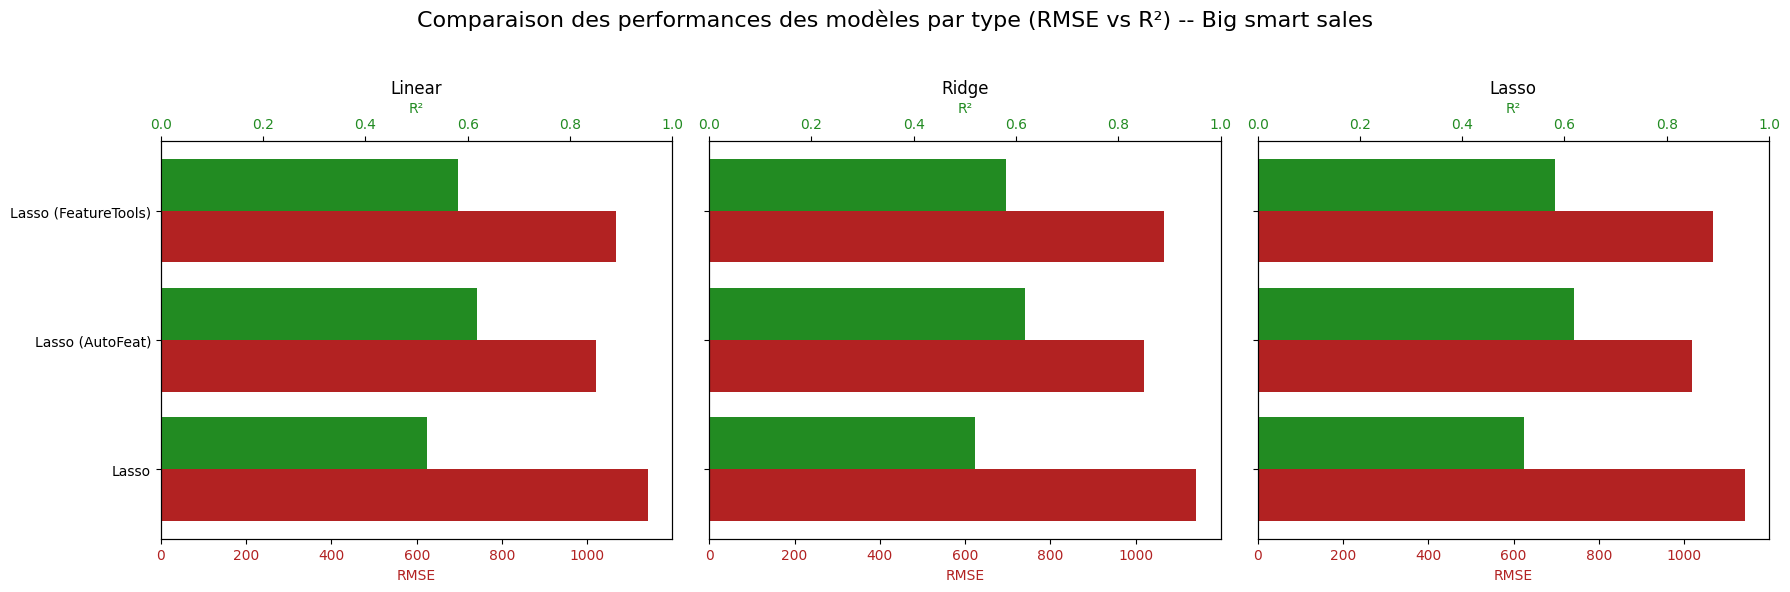

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Données organisées par type de modèle
model_groups = {
    "Linear": {
        "labels": ["Linear", "Linear (AutoFeat)", "Linear (FeatureTools)"],
        "rmse": [rmse, rmse_af, rmse_ft],
        "r2": [r2, r2_af, r2_ft]
    },
    "Ridge": {
        "labels": ["Ridge", "Ridge (AutoFeat)", "Ridge (FeatureTools)"],
        "rmse": [rmse_ridge, rmse_ridge_af, rmse_ridge_ft],
        "r2": [r2_ridge, r2_ridge_af, r2_ridge_ft]
    },
    "Lasso": {
        "labels": ["Lasso", "Lasso (AutoFeat)", "Lasso (FeatureTools)"],
        "rmse": [rmse_lasso, rmse_lasso_af, rmse_lasso_ft],
        "r2": [r2_lasso, r2_lasso_af, r2_lasso_ft]
    }
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (model_type, data) in enumerate(model_groups.items()):
    ax1 = axes[i]
    y = np.arange(len(data["labels"]))
    bar_height = 0.4

    # Axe principal : RMSE (rouge)
    ax1.barh(y - bar_height/2, data["rmse"], height=bar_height, color='firebrick', label='RMSE')
    ax1.set_xlabel('RMSE', color='firebrick')
    ax1.tick_params(axis='x', labelcolor='firebrick')
    ax1.set_yticks(y)
    ax1.set_yticklabels(data["labels"])
    ax1.set_title(model_type)

    # Axe secondaire : R² (vert)
    ax2 = ax1.twiny()
    ax2.barh(y + bar_height/2, data["r2"], height=bar_height, color='forestgreen', label='R²')
    ax2.set_xlim(0, 1)
    ax2.set_xlabel('R²', color='forestgreen')
    ax2.tick_params(axis='x', labelcolor='forestgreen')

fig.suptitle("Comparaison des performances des modèles par type (RMSE vs R²) -- Big smart sales", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
